### EN3160 Assignment 1
#### Intensity Transformations and Neighborhood Filtering

**Name** : Upekshani T. S. <br>
**Index Number** : 230659H <br>

**GitHub:** [EN3160 Assignment 1](https://github.com/shalaniupekshani/EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering)

#### Question 1 – Intensity Transformation

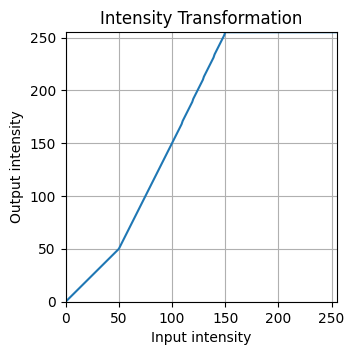

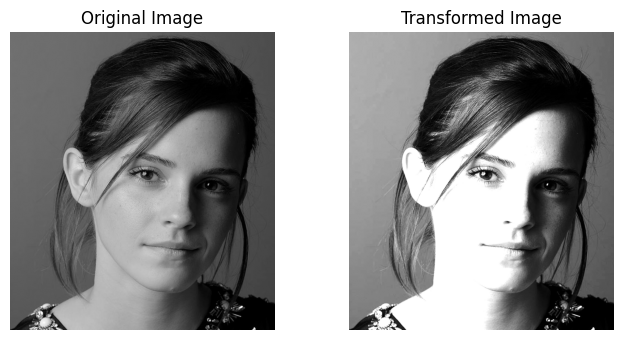

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    transform = np.zeros(256, dtype=np.uint8)

    for i in range(len(breakpoints)-1):
        x1,y1=breakpoints[i]
        x2,y2=breakpoints[i+1]
        x=np.arange(x1,x2+1)
        y=np.linspace(y1,y2,len(x))
        transform[x]=y.astype(np.uint8)

    transformed_image=cv.LUT(im,transform)

    return transformed_image,transform
    
breakpoints=np.array([(0,0),(50,50),(100,150),(150,255),(255,255)])
im=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q1\emma.jpg',cv.IMREAD_GRAYSCALE)

transformed_image, transform = intensity_transform(im,breakpoints)   


# Intensity transformation plot
plt.figure(figsize=(3.5, 3.5))

plt.plot(np.arange(256), transform)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid(True)
plt.show()


# Display images
plt.figure(figsize=(7, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(im, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transformed_image, cmap='gray')
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

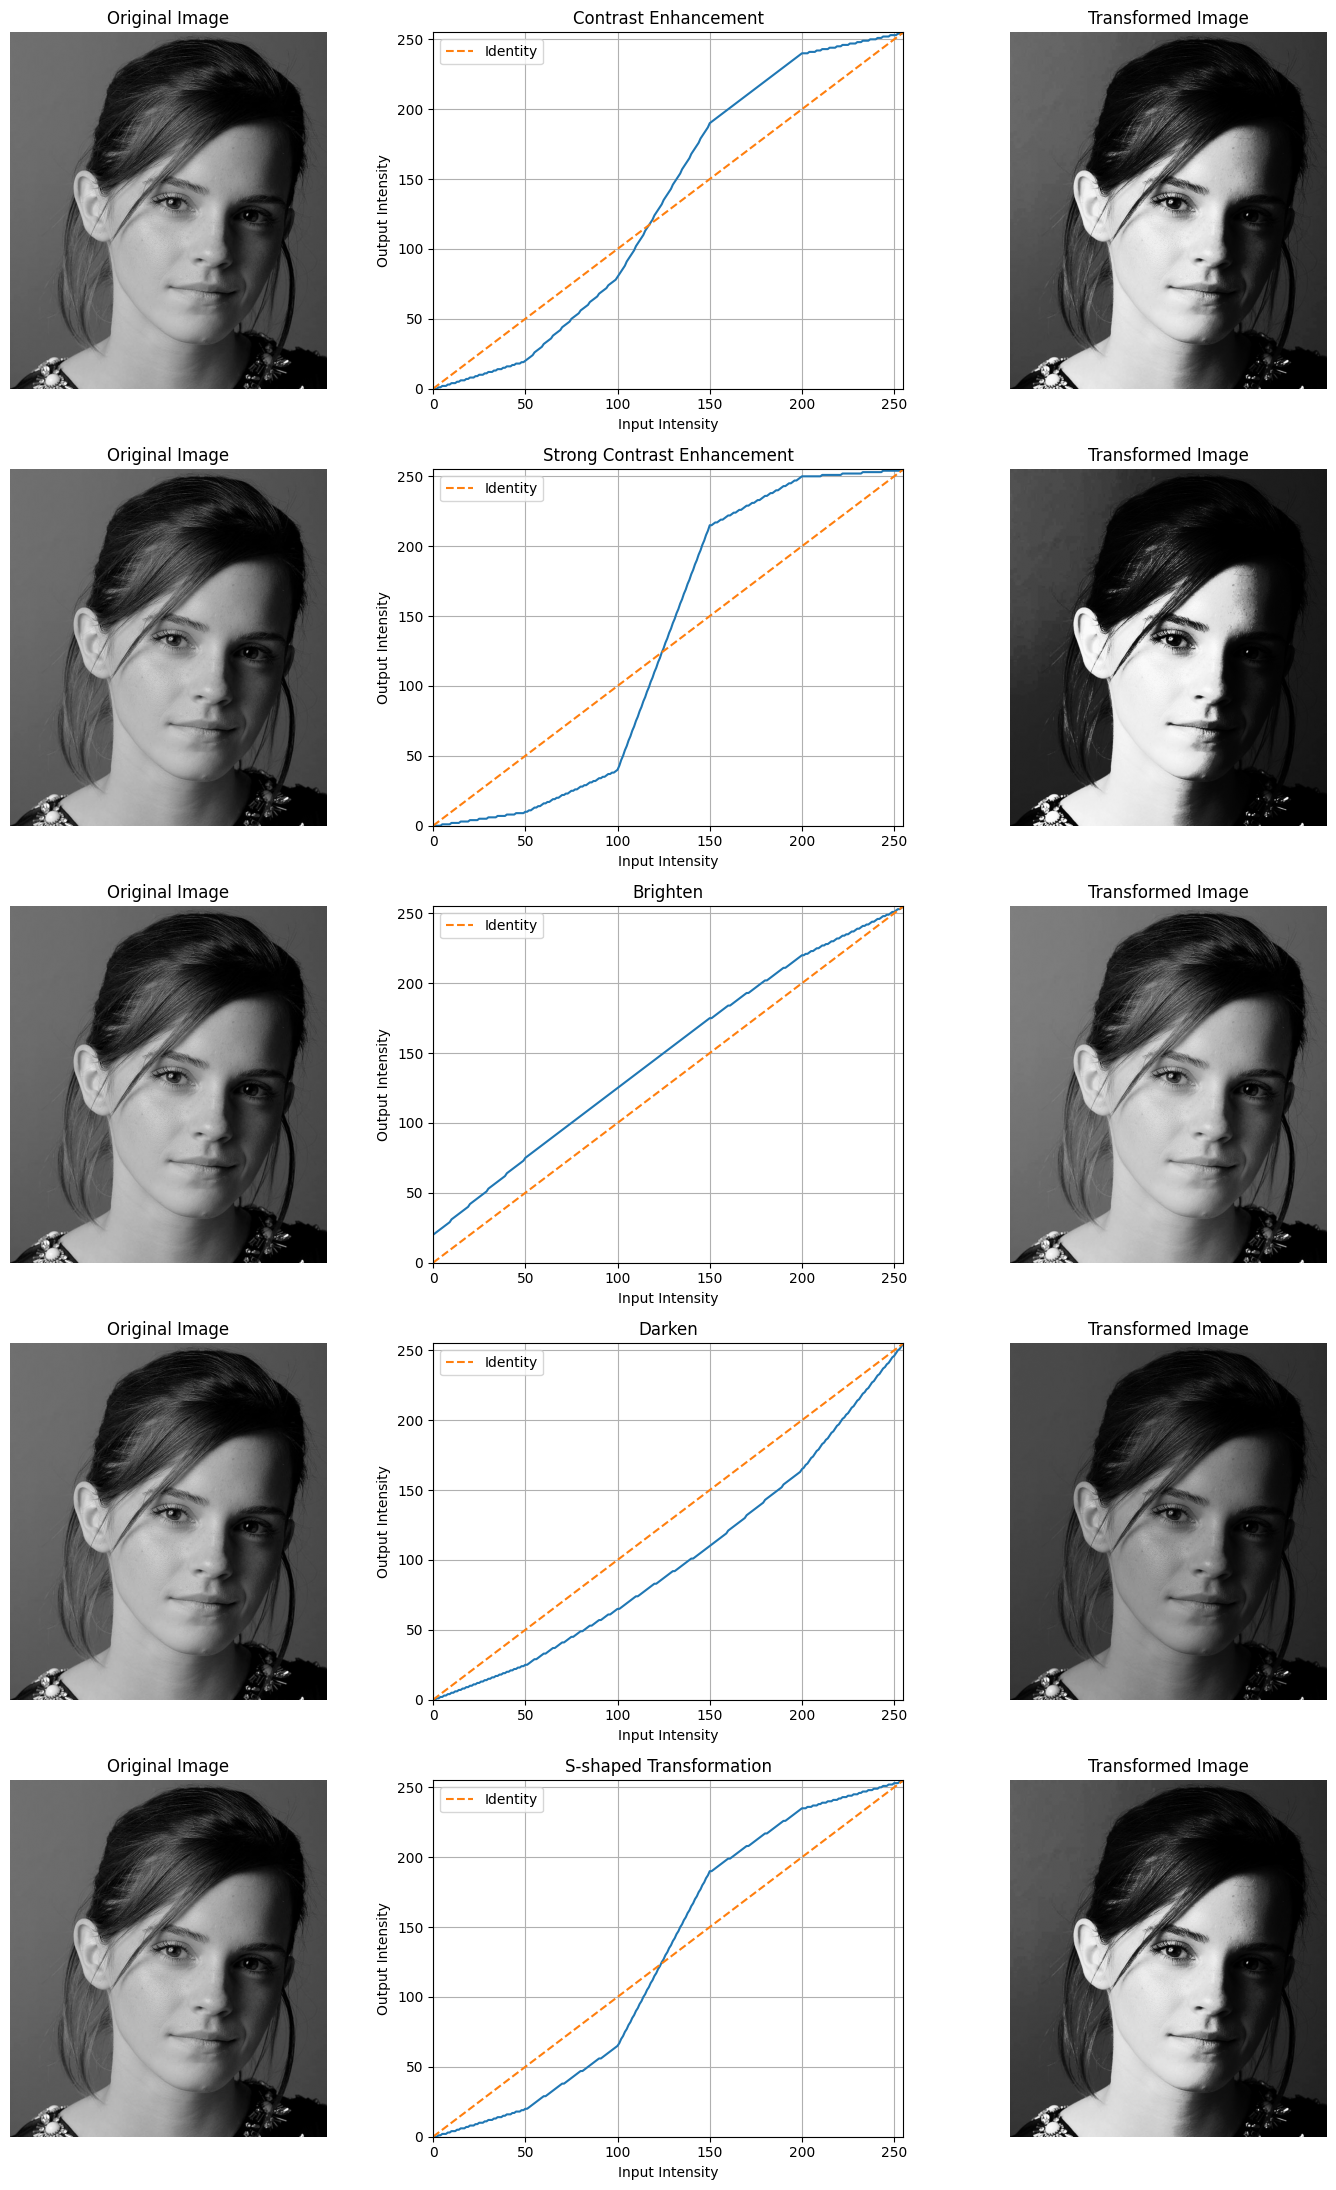

In [16]:
# Experiment with different breakpoints
# Contrast Enhancement - increase contrast in middle/high intensity range
breakpoints1=np.array([(0,0),(50,20),(100,80),(150,190),(200,240),(255,255)])

# Strong Contrast Enhancement - Dark pixel become dark and bright pixels become bright
breakpoints2=np.array([(0,0),(50,10),(100,40),(150,215),(200,250),(255,255)])

# Brighten the image - SHifting intensity upward
breakpoints3=np.array([(0,20),(50,75),(100,125),(150,175),(200,220),(255,255)])

# Darken the image
breakpoints4=np.array([(0,0),(50,25),(100,65),(150,110),(200,165),(255,255)])

# S-shaped transformation
breakpoints5=np.array([(0,0),(50,20),(100,65),(150,190),(200,235),(255,255)])

# Outputs
titles = [
    "Contrast Enhancement",
    "Strong Contrast Enhancement",
    "Brighten",
    "Darken",
    "S-shaped Transformation"
]

breakpoints_list = [breakpoints1, breakpoints2, breakpoints3, breakpoints4, breakpoints5]
fig, axes = plt.subplots(5, 3, figsize=(15, 22))

for i, (bp, title) in enumerate(zip(breakpoints_list, titles)):

    # Apply transformation
    transformed, transform = intensity_transform(im, bp)

    # Original image
    axes[i, 0].imshow(im, cmap='gray')
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    # Transformation graph
    axes[i, 1].plot(np.arange(256), transform)
    axes[i, 1].plot([0, 255], [0, 255], '--', label='Identity')

    axes[i, 1].set_title(title)
    axes[i, 1].set_xlabel("Input Intensity")
    axes[i, 1].set_ylabel("Output Intensity")
    axes[i, 1].set_xlim(0, 255)
    axes[i, 1].set_ylim(0, 255)
    axes[i, 1].grid(True)
    axes[i, 1].legend()

    # Transformed image
    axes[i, 2].imshow(transformed, cmap='gray')
    axes[i, 2].set_title("Transformed Image")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

#### Question 2 

Minimum intensity:  0
Maximum intensity:  255


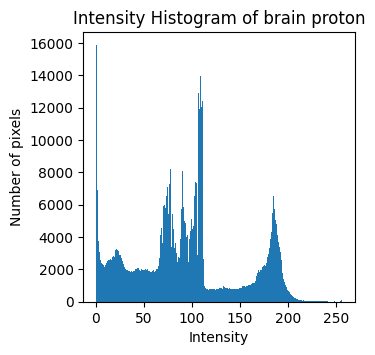

In [17]:
im2=cv.imread(r'C:\Users\shala\EN3160-Assignment1-on-Intensity-Transformations-and-Neighborhood-Filtering\images\Q2\brain proton.jpeg',cv.IMREAD_GRAYSCALE)
print("Minimum intensity: ",im.min())
print("Maximum intensity: ",im.max())

# Histogram
plt.figure(figsize=(3.5,3.5))
plt.hist(im.ravel(), bins=256, range=(0,256))
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Intensity Histogram of brain proton")
plt.show()

White matter - 170-190 <br>
Gray matter - 70-120

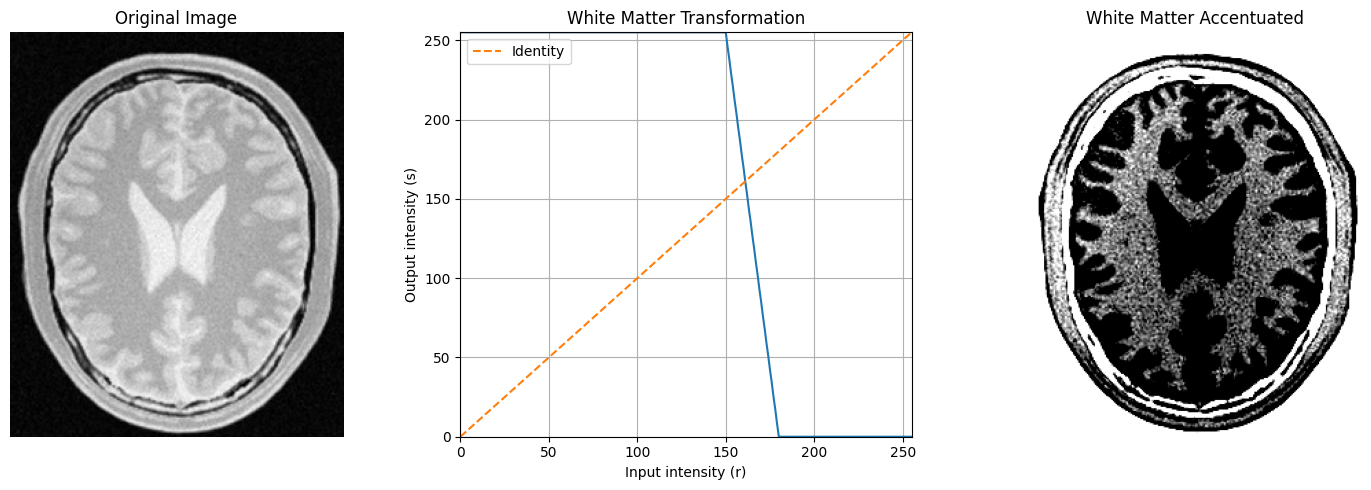

In [ ]:
wm_breakpoints=[(0,0),(150,0),(180,255),(255,255)]
wm_image,wm_transform=intensity_transform(im2, wm_breakpoints)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(im2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Transformation graph
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), wm_transform)
plt.plot([0, 255], [0, 255], "--", label="Identity")
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("White Matter Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
plt.legend()

# Output
plt.subplot(1, 3, 3)
plt.imshow(wm_image, cmap="gray")
plt.title("White Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()


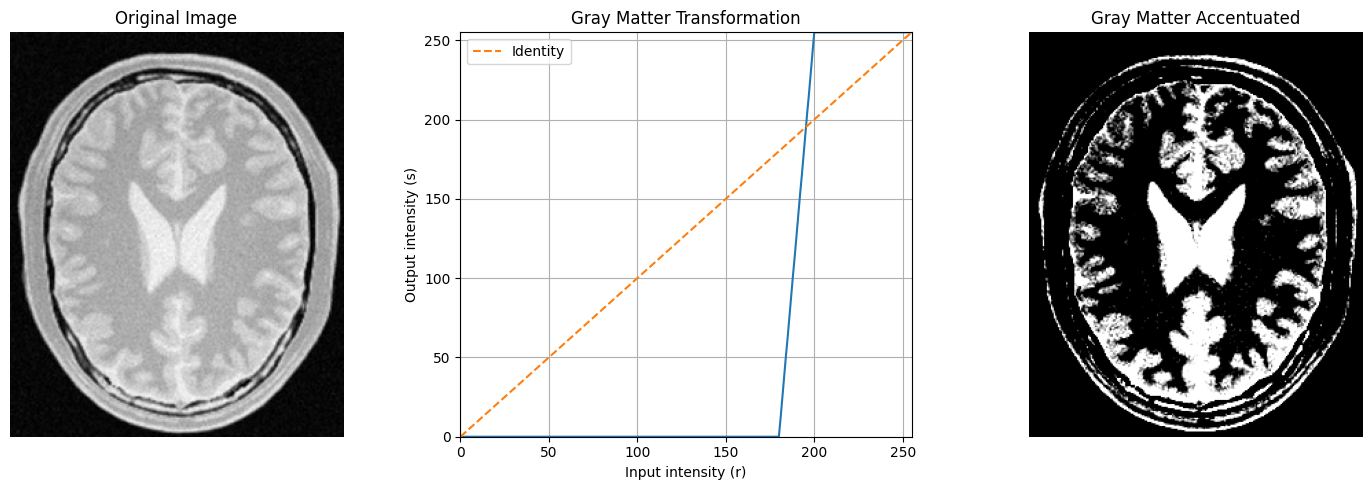

In [73]:
gm_breakpoints=[(0,0),(180,0),(200,255),(255,255)]
gm_image,gm_transform=intensity_transform(im2, gm_breakpoints)

plt.figure(figsize=(15, 5))

# Original
plt.subplot(1, 3, 1)
plt.imshow(im2, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Transformation graph
plt.subplot(1, 3, 2)
plt.plot(np.arange(256), gm_transform)
plt.plot([0, 255], [0, 255], "--", label="Identity")
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Gray Matter Transformation")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()
plt.legend()

# Output
plt.subplot(1, 3, 3)
plt.imshow(gm_image, cmap="gray")
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()
